<a href="https://colab.research.google.com/github/Leemyunglyul/ai_advanced/blob/main/%5BSDS%5DChap_4_text_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 텍스트 데이터 전처리

In [ ]:
!pip install kiwipiepy tiktoken wordcloud -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 8.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 20.9 MB/s eta 0:00:00


## 텍스트 정제

In [ ]:
text = "  배송이 너무 늦어요!!!  "
text = text.strip()
text = text.replace("!", "")
print(text)

배송이 너무 늦어요


In [ ]:
import re

text = "배송이   너무 늦어요!!! 주문번호는 12345입니다."
text = re.sub(r"\s+", " ", text) # 공백 여러 개를 한 개로 치환
text = re.sub(r"\d+", "", text) # 숫자를 빈 문자열로 치환
text = re.sub(r"[^가-힣a-zA-Z\s]", "", text) # 한글, 영문, 공백을 제외한 문자 제거
print(text)

배송이 너무 늦어요 주문번호는 입니다


In [ ]:
text = "<p>배송이 <b>너무</b> 늦어요!</p>"
cleaned = re.sub(r"<[^>]+>", "", text) # <내용>의 형태로 생긴 문자열 매칭
print(cleaned)

배송이 너무 늦어요!


## 텍스트 정규화

In [ ]:
text = "WOWㅋㅋㅋㅋㅋ 배송일은 2026/08/30입니다."
text = text.lower() # 영문 대소문자 통일
text = re.sub(r"ㅋ{3,}", "ㅋㅋ", text) # 반복 문자 통일
text = re.sub(r"(\d{4})/(\d{2})/(\d{2})", r"\1-\2-\3", text) # 날짜 표현 형식 통일
print(text)

wowㅋㅋ 배송일은 2026-08-30입니다.


## 텍스트 분할 및 가공 (변환)

In [ ]:
text = "오늘 날씨가 정말 좋다"
tokens = text.split(' ') # 공백 구분자를 기준으로 문자열 분할 (토큰화)
print(tokens)

['오늘', '날씨가', '정말', '좋다']


In [ ]:
text1 = "나는 학교에 간다"       # text2의 학교와 같은 의미의 학교 포함
text2 = "너는 학교에서 공부한다" # text1의 학교와 같은 의미의 학교 포함
tokens = []

for text in [text1, text2]:
    tokens.extend(text.split(' '))
tokens = list(set(tokens))
print(tokens) #  조사 때문에 학교에, 학교에서로 다르게 표현

['공부한다', '간다', '학교에', '나는', '너는', '학교에서']


In [ ]:
from kiwipiepy import Kiwi

kiwi = Kiwi() # 키위파이파이 형태소 분석기 추가
text = "오늘 날씨가 정말 좋다"
tokens = kiwi.tokenize(text) # 형태소 기반 토큰화 수행 (토큰, 품사 등 반환)
tokens

[Token(form='오늘', tag='NNG', start=0, len=2),
 Token(form='날씨', tag='NNG', start=3, len=2),
 Token(form='가', tag='JKS', start=5, len=1),
 Token(form='정말', tag='MAG', start=7, len=2),
 Token(form='좋', tag='VA', start=10, len=1),
 Token(form='다', tag='EF', start=11, len=1)]

In [ ]:
import tiktoken

encoder = tiktoken.get_encoding("cl100k_base") # OpenAI의 100k 어휘 집합
text = "오늘 날씨가 정말 좋다"
token_ids = encoder.encode(text)
tokens = [encoder.decode([token_id]) for token_id in token_ids]
print(tokens) # 분할된 부분 단어 토큰
print(token_ids) # 정수로 변환된 부분 단어 토큰

['오', '�', '�', ' �', '�', '�', '�', '�', '가', ' 정', '�', '�', ' �', '�', '다']
[58368, 15478, 246, 38295, 254, 168, 242, 101, 20565, 37155, 40011, 238, 66799, 233, 13447]


In [ ]:
import pandas as pd

texts = ["오늘 날씨가 정말 좋다",
         "배송이 너무 늦어요",
         "상품의 품질이 만족스럽습니다"]
df = pd.DataFrame(texts, columns=['texts'])
display(df)

,texts
0,오늘 날씨가 정말 좋다
1,배송이 너무 늦어요
2,상품의 품질이 만족스럽습니다


In [ ]:
df["tokens"] = df["texts"].str.split(" ") # 공백 기반 토큰화
df["morphemes"] = df["texts"].apply(      # 형태소 기반 토큰화
    lambda x: [token.form for token in kiwi.tokenize(x)])
df["token_ids"] = df["texts"].apply(encoder.encode) # 부분 단어 기반 토큰화
display(df)

,texts,tokens,morphemes,token_ids
0,오늘 날씨가 정말 좋다,"[오늘, 날씨가, 정말, 좋다]","[오늘, 날씨, 가, 정말, 좋, 다]","[58368, 15478, 246, 38295, 254, 168, 242, 101,..."
1,배송이 너무 늦어요,"[배송이, 너무, 늦어요]","[배송, 이, 너무, 늦, 어요]","[39277, 108, 35677, 94, 13094, 66653, 230, 167..."
2,상품의 품질이 만족스럽습니다,"[상품의, 품질이, 만족스럽습니다]","[상품, 의, 품질, 이, 만족, 스럽, 습니다]","[57002, 169, 240, 230, 21028, 10997, 240, 230,..."


## 텍스트 데이터 통계

In [ ]:
df["char_count"] = df["texts"].str.len()  # 텍스트의 문자 수
df["word_count"] = df["tokens"].str.len() # 텍스트의 단어/토큰 수
display(df[["texts", "char_count", "word_count"]])

,texts,char_count,word_count
0,오늘 날씨가 정말 좋다,12,4
1,배송이 너무 늦어요,10,3
2,상품의 품질이 만족스럽습니다,15,3


In [ ]:
df[["char_count", "word_count"]].describe() # 기본 통계 요약

,char_count,word_count
count,3.000000,3.000000
mean,12.333333,3.333333
std,2.516611,0.577350
min,10.000000,3.000000
25%,11.000000,3.000000
50%,12.000000,3.000000
75%,13.500000,3.500000
max,15.000000,4.000000


In [ ]:
df["tokens"].explode().value_counts()

,count
tokens,
오늘,1
날씨가,1
정말,1
좋다,1
배송이,1
너무,1
늦어요,1
상품의,1
품질이,1


In [ ]:
from collections import Counter

words = df["texts"].str.split().explode() # 묶인 데이터 (리스트)를 폭파
word_counts1 = words.value_counts() # 판다스를 이용한 토큰 별 빈도
word_counts2 = Counter(words.values.tolist()) # 카운터를 이용한 토큰 별 빈도
print(word_counts1, word_counts2, sep="\n")

texts
오늘         1
날씨가        1
정말         1
좋다         1
배송이        1
너무         1
늦어요        1
상품의        1
품질이        1
만족스럽습니다    1
Name: count, dtype: int64
Counter({'오늘': 1, '날씨가': 1, '정말': 1, '좋다': 1, '배송이': 1, '너무': 1, '늦어요': 1, '상품의': 1, '품질이': 1, '만족스럽습니다': 1})


In [ ]:
import random
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [ ]:
random.seed(42)

subjects = ["배송", "상품", "포장", "가격", "품질", "서비스", "응대"]
positives = ["좋아요", "만족", "빠름", "친절", "추천", "깔끔", "우수"]
negatives = ["느려요", "별로", "아쉬움", "불만", "늦음", "불편", "문제"]
adverbs = ["정말", "아주", "조금", "너무", "꽤", "매우"]

positive_pool = (
    ["좋아요"] * 12 +
    ["만족"] * 10 +
    ["추천"] * 8 +
    ["빠름"] * 7 +
    ["친절"] * 6 +
    ["깔끔"] * 5 +
    ["우수"] * 4
)

negative_pool = (
    ["느려요"] * 10 +
    ["아쉬움"] * 8 +
    ["불만"] * 7 +
    ["늦음"] * 6 +
    ["불편"] * 5 +
    ["문제"] * 4 +
    ["별로"] * 4
)

rows = []

for _ in range(200):
    subject = random.choice(subjects)
    adverb = random.choice(adverbs)

    # 긍정 리뷰를 조금 더 많게
    if random.random() < 0.65:
        opinion = random.choice(positive_pool)
    else:
        opinion = random.choice(negative_pool)

    text = f"{subject} {adverb} {opinion}"
    rows.append(text)
df = pd.DataFrame({"text": rows})
df.head()

,text
0,서비스 정말 만족
1,상품 아주 좋아요
2,서비스 매우 느려요
3,품질 너무 좋아요
4,상품 아주 좋아요


In [ ]:
random.seed(42)

subjects = ["delivery", "product", "packaging", "price", "quality", "service", "support"]
adverbs = ["very", "really", "quite", "extremely", "slightly", "truly"]

positive_pool = (
    ["good"] * 12 +
    ["great"] * 10 +
    ["excellent"] * 8 +
    ["fast"] * 7 +
    ["friendly"] * 6 +
    ["clean"] * 5 +
    ["recommended"] * 4
)

negative_pool = (
    ["slow"] * 10 +
    ["bad"] * 8 +
    ["poor"] * 7 +
    ["late"] * 6 +
    ["uncomfortable"] * 5 +
    ["problematic"] * 4 +
    ["disappointing"] * 4
)

rows = []

for _ in range(200):
    subject = random.choice(subjects)
    adverb = random.choice(adverbs)

    if random.random() < 0.65:
        opinion = random.choice(positive_pool)
    else:
        opinion = random.choice(negative_pool)

    text = f"{subject} is {adverb} {opinion}"
    rows.append(text)

df = pd.DataFrame({"text": rows})

df.head()

,text
0,service is very great
1,product is really good
2,service is truly slow
3,quality is extremely good
4,product is really good


In [ ]:
df["tokens"] = df["text"].apply(lambda x: x.split())
df.head()

,text,tokens
0,service is very great,"[service, is, very, great]"
1,product is really good,"[product, is, really, good]"
2,service is truly slow,"[service, is, truly, slow]"
3,quality is extremely good,"[quality, is, extremely, good]"
4,product is really good,"[product, is, really, good]"


In [ ]:
word_counts = df["tokens"].explode().value_counts()
print(word_counts.head(10))

tokens
is           200
very          43
extremely     36
truly         32
quality       32
service       31
really        31
product       31
price         31
quite         30
Name: count, dtype: int64


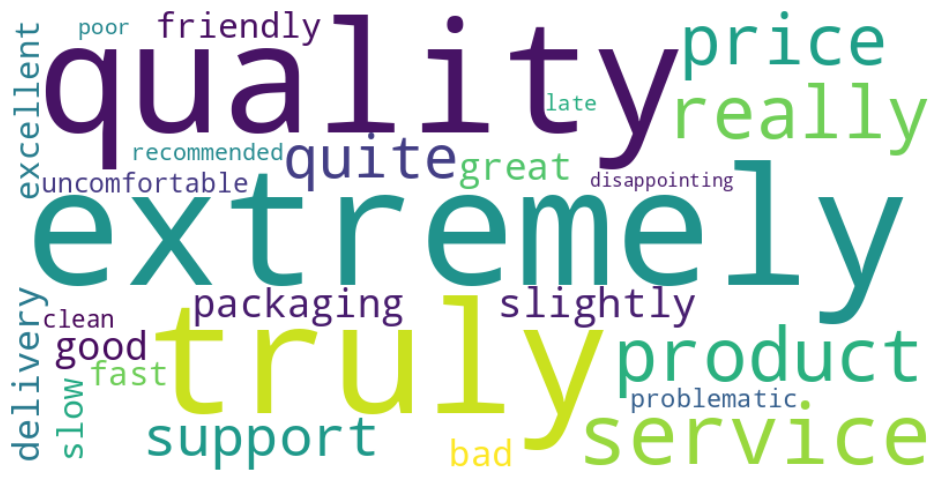

In [ ]:
text_for_cloud = " ".join(df["tokens"].explode().tolist())

wc = WordCloud(
    # font_path="C:/Windows/Fonts/malgun.ttf",  # 윈도우 한글 폰트
    width=800,
    height=400,
    background_color="white"
).generate(text_for_cloud)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()